In [228]:
# loading the customer churn dataset
import pandas as pd
import numpy as np
dataset=pd.read_csv(r"C:\Users\Lenovo\Downloads\archive\customer_churn_dataset-training-master.csv")

In [229]:
dataset

,CustomerID,Age,Gender,Tenure,Usage Frequency,Support Calls,Payment Delay,Subscription Type,Contract Length,Total Spend,Last Interaction,Churn
0,2.0,30.0,Female,39.0,14.0,5.0,18.0,Standard,Annual,932.00,17.0,1.0
1,3.0,65.0,Female,49.0,1.0,10.0,8.0,Basic,Monthly,557.00,6.0,1.0
2,4.0,55.0,Female,14.0,4.0,6.0,18.0,Basic,Quarterly,185.00,3.0,1.0
3,5.0,58.0,Male,38.0,21.0,7.0,7.0,Standard,Monthly,396.00,29.0,1.0
4,6.0,23.0,Male,32.0,20.0,5.0,8.0,Basic,Monthly,617.00,20.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...
440828,449995.0,42.0,Male,54.0,15.0,1.0,3.0,Premium,Annual,716.38,8.0,0.0
440829,449996.0,25.0,Female,8.0,13.0,1.0,20.0,Premium,Annual,745.38,2.0,0.0
440830,449997.0,26.0,Male,35.0,27.0,1.0,5.0,Standard,Quarterly,977.31,9.0,0.0
440831,449998.0,28.0,Male,55.0,14.0,2.0,0.0,Standard,Quarterly,602.55,2.0,0.0


In [230]:
print("Dataset information:\n") 
infoOfDataset=dataset.info()
print(infoOfDataset)

Dataset information:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 440833 entries, 0 to 440832
Data columns (total 12 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   CustomerID         440832 non-null  float64
 1   Age                440832 non-null  float64
 2   Gender             440832 non-null  object 
 3   Tenure             440832 non-null  float64
 4   Usage Frequency    440832 non-null  float64
 5   Support Calls      440832 non-null  float64
 6   Payment Delay      440832 non-null  float64
 7   Subscription Type  440832 non-null  object 
 8   Contract Length    440832 non-null  object 
 9   Total Spend        440832 non-null  float64
 10  Last Interaction   440832 non-null  float64
 11  Churn              440832 non-null  float64
dtypes: float64(9), object(3)
memory usage: 40.4+ MB
None


In [231]:
print("Numerical Columns:\n") 
numerical=dataset.select_dtypes(include=["int64","float64"])
print(numerical.columns)

Numerical Columns:

Index(['CustomerID', 'Age', 'Tenure', 'Usage Frequency', 'Support Calls',
       'Payment Delay', 'Total Spend', 'Last Interaction', 'Churn'],
      dtype='object')


In [232]:
print("Categorical Columns:\n") 
categorical=dataset.select_dtypes(include=["object"])
print(categorical.columns)

Categorical Columns:

Index(['Gender', 'Subscription Type', 'Contract Length'], dtype='object')


In [233]:
TotalNoOfRecords=len(dataset)
print("Total Number of records in this dataset are:", TotalNoOfRecords)

Total Number of records in this dataset are: 440833


In [234]:
# Cleaning & Pre-processing
duplicated_rows=dataset[dataset.duplicated()]
if len(duplicated_rows)>0:
    print("Duplicate records found:")
    print(duplicated_rows)
else:
    print("No duplicate records found.")

No duplicate records found.


In [235]:
missing=dataset.isnull().sum()
print("Missing values in each column:")
print(missing)

Missing values in each column:
CustomerID           1
Age                  1
Gender               1
Tenure               1
Usage Frequency      1
Support Calls        1
Payment Delay        1
Subscription Type    1
Contract Length      1
Total Spend          1
Last Interaction     1
Churn                1
dtype: int64


In [236]:
missing_rows=dataset[dataset.isnull().any(axis=1)]
if len(missing_rows)>0:
    print("Records with missing values:")
    print(missing_rows)
else:
    print("No missing values found.")

Records with missing values:
        CustomerID  Age Gender  Tenure  Usage Frequency  Support Calls  \
199295         NaN  NaN    NaN     NaN              NaN            NaN   

        Payment Delay Subscription Type Contract Length  Total Spend  \
199295            NaN               NaN             NaN          NaN   

        Last Interaction  Churn  
199295               NaN    NaN  


In [237]:
dataset=dataset.fillna(dataset.mean(numeric_only=True))
print("Missing values have been filled with the mean.")

Missing values have been filled with the mean.


In [238]:
TotalNoOfRecords=len(dataset)
print("Total Number of records in this dataset are:", TotalNoOfRecords)

Total Number of records in this dataset are: 440833


In [239]:
dataset

,CustomerID,Age,Gender,Tenure,Usage Frequency,Support Calls,Payment Delay,Subscription Type,Contract Length,Total Spend,Last Interaction,Churn
0,2.0,30.0,Female,39.0,14.0,5.0,18.0,Standard,Annual,932.00,17.0,1.0
1,3.0,65.0,Female,49.0,1.0,10.0,8.0,Basic,Monthly,557.00,6.0,1.0
2,4.0,55.0,Female,14.0,4.0,6.0,18.0,Basic,Quarterly,185.00,3.0,1.0
3,5.0,58.0,Male,38.0,21.0,7.0,7.0,Standard,Monthly,396.00,29.0,1.0
4,6.0,23.0,Male,32.0,20.0,5.0,8.0,Basic,Monthly,617.00,20.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...
440828,449995.0,42.0,Male,54.0,15.0,1.0,3.0,Premium,Annual,716.38,8.0,0.0
440829,449996.0,25.0,Female,8.0,13.0,1.0,20.0,Premium,Annual,745.38,2.0,0.0
440830,449997.0,26.0,Male,35.0,27.0,1.0,5.0,Standard,Quarterly,977.31,9.0,0.0
440831,449998.0,28.0,Male,55.0,14.0,2.0,0.0,Standard,Quarterly,602.55,2.0,0.0


In [240]:
print(dataset.isnull().sum())

CustomerID           0
Age                  0
Gender               1
Tenure               0
Usage Frequency      0
Support Calls        0
Payment Delay        0
Subscription Type    1
Contract Length      1
Total Spend          0
Last Interaction     0
Churn                0
dtype: int64


In [241]:
dataset["Gender"]=dataset["Gender"].fillna(dataset["Gender"].mode()[0])
print("Missing values in the Gender column have been filled with the mode.")

Missing values in the Gender column have been filled with the mode.


In [242]:
dataset["Subscription Type"]=dataset["Subscription Type"].fillna(dataset["Subscription Type"].mode()[0])
print("Missing values in the Subscription Type column have been filled with the mode.")

Missing values in the Subscription Type column have been filled with the mode.


In [243]:
dataset["Contract Length"]=dataset["Contract Length"].fillna(dataset["Contract Length"].mode()[0])
print("Missing values in the Contract Length column have been filled with the mode.")

Missing values in the Contract Length column have been filled with the mode.


In [244]:
print(dataset.isnull().sum())

CustomerID           0
Age                  0
Gender               0
Tenure               0
Usage Frequency      0
Support Calls        0
Payment Delay        0
Subscription Type    0
Contract Length      0
Total Spend          0
Last Interaction     0
Churn                0
dtype: int64


In [245]:
print(dataset.dtypes)

CustomerID           float64
Age                  float64
Gender                object
Tenure               float64
Usage Frequency      float64
Support Calls        float64
Payment Delay        float64
Subscription Type     object
Contract Length       object
Total Spend          float64
Last Interaction     float64
Churn                float64
dtype: object


In [246]:
dataset["CustomerID"]=dataset["CustomerID"].astype(int)
dataset["Age"]=dataset["Age"].astype(int)
dataset["Tenure"]=dataset["Tenure"].astype(int)
dataset["Usage Frequency"]=dataset["Usage Frequency"].astype(int)
dataset["Support Calls"]=dataset["Support Calls"].astype(int)
dataset["Payment Delay"]=dataset["Payment Delay"].astype(int)
dataset["Last Interaction"]=dataset["Last Interaction"].astype(int)
dataset["Churn"]=dataset["Churn"].astype(int)

In [247]:
print(dataset.dtypes)

CustomerID             int64
Age                    int64
Gender                object
Tenure                 int64
Usage Frequency        int64
Support Calls          int64
Payment Delay          int64
Subscription Type     object
Contract Length       object
Total Spend          float64
Last Interaction       int64
Churn                  int64
dtype: object


In [248]:
# removing CustomerID as it is just an identifier and will not actually influence the prediction
dataset=dataset.drop("CustomerID", axis=1)

In [249]:
dataset

,Age,Gender,Tenure,Usage Frequency,Support Calls,Payment Delay,Subscription Type,Contract Length,Total Spend,Last Interaction,Churn
0,30,Female,39,14,5,18,Standard,Annual,932.00,17,1
1,65,Female,49,1,10,8,Basic,Monthly,557.00,6,1
2,55,Female,14,4,6,18,Basic,Quarterly,185.00,3,1
3,58,Male,38,21,7,7,Standard,Monthly,396.00,29,1
4,23,Male,32,20,5,8,Basic,Monthly,617.00,20,1
...,...,...,...,...,...,...,...,...,...,...,...
440828,42,Male,54,15,1,3,Premium,Annual,716.38,8,0
440829,25,Female,8,13,1,20,Premium,Annual,745.38,2,0
440830,26,Male,35,27,1,5,Standard,Quarterly,977.31,9,0
440831,28,Male,55,14,2,0,Standard,Quarterly,602.55,2,0


In [250]:
print("Summary Statistics:\n") 
summaryOfDataset=dataset.describe()
print(summaryOfDataset)

Summary Statistics:

                 Age         Tenure  Usage Frequency  Support Calls  \
count  440833.000000  440833.000000    440833.000000  440833.000000   
mean       39.373153      31.256335        15.807492       3.604435   
std        12.442355      17.255708         8.586232       3.070215   
min        18.000000       1.000000         1.000000       0.000000   
25%        29.000000      16.000000         9.000000       1.000000   
50%        39.000000      32.000000        16.000000       3.000000   
75%        48.000000      46.000000        23.000000       6.000000   
max        65.000000      60.000000        30.000000      10.000000   

       Payment Delay    Total Spend  Last Interaction          Churn  
count  440833.000000  440833.000000     440833.000000  440833.000000  
mean       12.965719     631.616223         14.480867       0.567106  
std         8.258053     240.802728          8.596198       0.495477  
min         0.000000     100.000000          1.000000  

In [251]:
from sklearn.preprocessing import LabelEncoder
import joblib
catColumns = ["Gender", "Subscription Type", "Contract Length"]
encoders = {}
for column in catColumns:
    encoder = LabelEncoder()
    dataset[column] = encoder.fit_transform(dataset[column])
    encoders[column] = encoder
joblib.dump(encoders, "encoders.pkl")

['encoders.pkl']

In [252]:
dataset

,Age,Gender,Tenure,Usage Frequency,Support Calls,Payment Delay,Subscription Type,Contract Length,Total Spend,Last Interaction,Churn
0,30,0,39,14,5,18,2,0,932.00,17,1
1,65,0,49,1,10,8,0,1,557.00,6,1
2,55,0,14,4,6,18,0,2,185.00,3,1
3,58,1,38,21,7,7,2,1,396.00,29,1
4,23,1,32,20,5,8,0,1,617.00,20,1
...,...,...,...,...,...,...,...,...,...,...,...
440828,42,1,54,15,1,3,1,0,716.38,8,0
440829,25,0,8,13,1,20,1,0,745.38,2,0
440830,26,1,35,27,1,5,2,2,977.31,9,0
440831,28,1,55,14,2,0,2,2,602.55,2,0


In [253]:
# Visualizing key insights
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style("whitegrid")

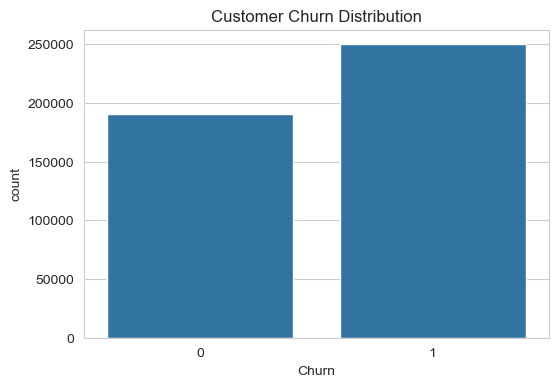

In [254]:
plt.figure(figsize=(6,4))
sns.countplot(x="Churn", data=dataset)
plt.title("Customer Churn Distribution")
plt.show()

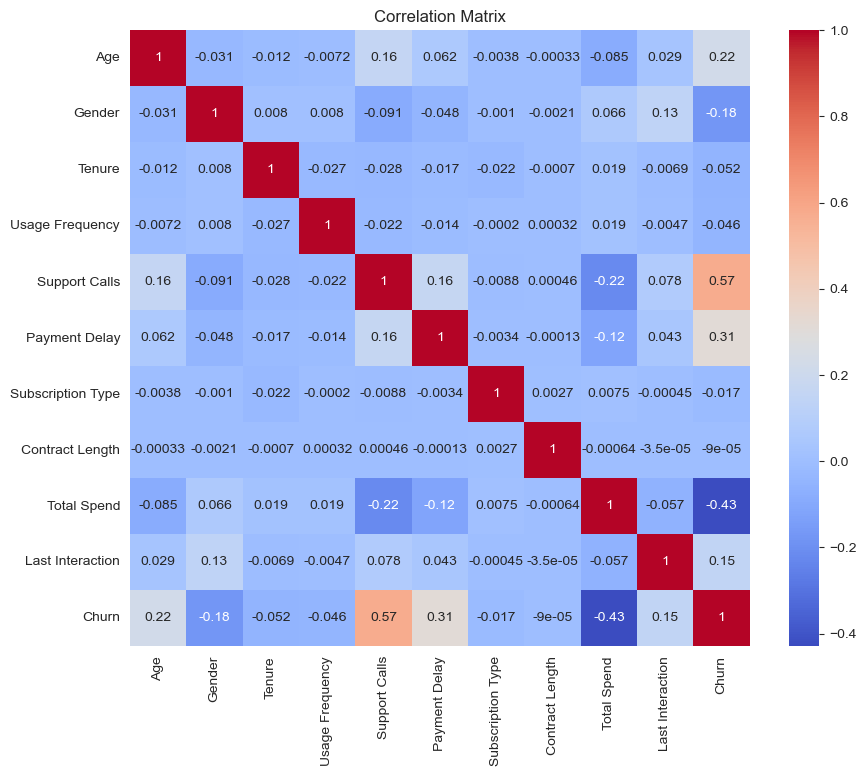

In [255]:
plt.figure(figsize=(10,8))
sns.heatmap(dataset.corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()

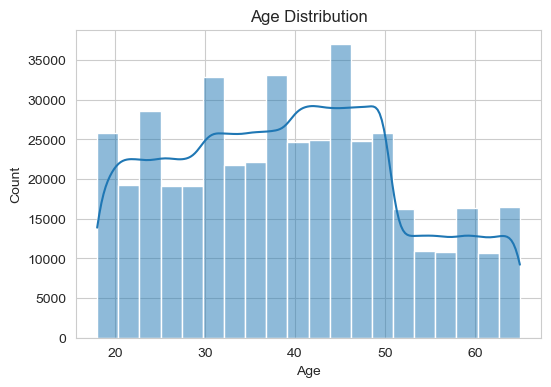

In [256]:
plt.figure(figsize=(6,4))
sns.histplot(dataset["Age"], bins=20, kde=True)
plt.title("Age Distribution")
plt.show()

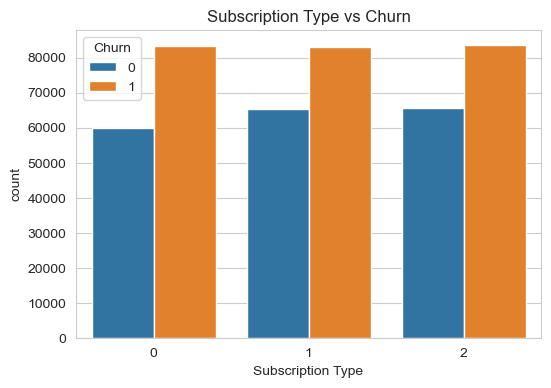

In [257]:
plt.figure(figsize=(6,4))
sns.countplot(x="Subscription Type", hue="Churn", data=dataset)
plt.title("Subscription Type vs Churn")
plt.show()

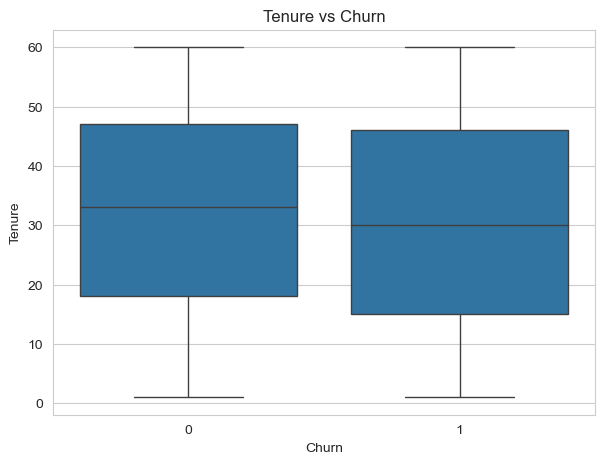

In [258]:
plt.figure(figsize=(7,5))
sns.boxplot(x="Churn", y="Tenure", data=dataset)
plt.title("Tenure vs Churn")
plt.show()

In [259]:
features= dataset.drop("Churn", axis=1)
label= dataset["Churn"]

In [260]:
from sklearn.model_selection import train_test_split
features_train, features_test, label_train, label_test = train_test_split(
    features,
    label,
    test_size=0.2,
    random_state=42
)

In [261]:
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
features_train=scaler.fit_transform(features_train)
features_test=scaler.transform(features_test)
joblib.dump(scaler, "scaler.pkl")

['scaler.pkl']

In [262]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier

logisticRegression = LogisticRegression(max_iter=1000)

decisionTree = DecisionTreeClassifier(
    max_depth=10,
    min_samples_split=20,
    min_samples_leaf=10,
    random_state=42
)

randomForest=RandomForestClassifier(
    n_estimators=200,
    max_depth=15,
    min_samples_split=10,
    random_state=42
)

knn = KNeighborsClassifier()

bestModels = {
    "Logistic Regression": logisticRegression,
    "Decision Tree": decisionTree,
    "Random Forest": randomForest,
    "KNN": knn
}

for model in bestModels.values():
    model.fit(features_train, label_train)

In [263]:
from sklearn.metrics import accuracy_score

accuracies={}

for name, model in bestModels.items():
    prediction=model.predict(features_test)
    accuracy=accuracy_score(label_test, prediction)

    accuracies[name]= accuracy

    print(name)
    print("Accuracy:", accuracy)
    print()

Logistic Regression
Accuracy: 0.852688647679971

Decision Tree
Accuracy: 0.9963591820068733

Random Forest
Accuracy: 0.9992741048238003

KNN
Accuracy: 0.960370660224347



In [264]:
bestModel= max(accuracies, key=accuracies.get)

print("Best Model:", bestModel)
print("Accuracy:", accuracies[bestModel])

Best Model: Random Forest
Accuracy: 0.9992741048238003


In [265]:
joblib.dump(bestModels[bestModel], "best_model.pkl")

['best_model.pkl']

In [266]:
newCustomer=[[35, 1, 2, 24, 15, 2, 5, 250.5, 30, 1]]

newCustomer=scaler.transform(newCustomer)

prediction=bestModels[bestModel].predict(newCustomer)

if prediction[0]== 1:
    print("Customer is likely to churn.")
else:
    print("Customer is not likely to churn.")

Customer is likely to churn.


C:\Users\Lenovo\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


In [267]:
import pandas as pd

testData=pd.read_csv(r"C:\Users\Lenovo\Downloads\archive\customer_churn_dataset-testing-master.csv")

features_external=testData.drop("Churn", axis=1)

if "CustomerID" in features_external.columns:
    features_external=features_external.drop("CustomerID", axis=1)

encoders=joblib.load("encoders.pkl")

for column in catColumns:
    features_external[column]=encoders[column].transform(features_external[column])

features_external=scaler.transform(features_external)

prediction=bestModels[bestModel].predict(features_external)

In [268]:
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

print("Accuracy:", accuracy_score(testData["Churn"], prediction))
print(confusion_matrix(testData["Churn"], prediction))
print(classification_report(testData["Churn"], prediction))

Accuracy: 0.5038680212508155
[[ 1990 31891]
 [   47 30446]]
              precision    recall  f1-score   support

           0       0.98      0.06      0.11     33881
           1       0.49      1.00      0.66     30493

    accuracy                           0.50     64374
   macro avg       0.73      0.53      0.38     64374
weighted avg       0.75      0.50      0.37     64374



In [269]:
result=testData.copy()

result["Prediction"]=prediction

result.to_csv("prediction_report_testing.csv", index=False)

print("Prediction report saved successfully.")

Prediction report saved successfully.


In [ ]:
'''
from sklearn.linear_model import LogisticRegression
lr = LogisticRegression(max_iter=1000)
lr.fit(features_train, label_train)'''

In [ ]:
'''from sklearn.tree import DecisionTreeClassifier
dt = DecisionTreeClassifier(random_state=42)
dt.fit(features_train, label_train)'''

In [ ]:
'''from sklearn.ensemble import RandomForestClassifier
rf = RandomForestClassifier(random_state=42)
rf.fit(features_train, label_train)'''

In [ ]:
'''from sklearn.neighbors import KNeighborsClassifier
knn = KNeighborsClassifier()
knn.fit(features_train, label_train)'''

In [ ]:
'''from sklearn.metrics import accuracy_score
models = {
    "Logistic Regression": lr,
    "Decision Tree": dt,
    "Random Forest": rf,
    "KNN": knn
}
scores = {}
for name, model in models.items():
    prediction= model.predict(features_test)
    accuracy= accuracy_score(label_test, prediction)
    scores[name]= accuracy
    print(name, "Accuracy:", accuracy)'''

In [ ]:
'''from sklearn.metrics import classification_report, confusion_matrix
prediction= rf.predict(features_test)
print(confusion_matrix(label_test, prediction))
print(classification_report(label_test, prediction))'''

In [ ]:
'''bestModel=max(scores, key=scores.get)
print("Best Model:", bestModel)
print("Accuracy:", scores[bestModel])'''

In [ ]:
'''import joblib
bestModels={
    "Logistic Regression": lr,
    "Decision Tree": dt,
    "Random Forest": rf,
    "KNN": knn
}
joblib.dump(bestModels[bestModel], "best_customer_churn_model.pkl")
print("Model saved successfully.")'''

In [ ]:
'''joblib.dump(scaler, "scaler.pkl")'''

In [ ]:
'''newCustomer=[[35, 1, 2, 24, 15, 2, 5, 250.5, 30, 1]]
newCustomer = scaler.transform(newCustomer)
prediction = bestModels[bestModel].predict(newCustomer)
if prediction[0] == 1:
    print("Customer is likely to churn.")
else:
    print("Customer is not likely to churn.")'''

In [ ]:
'''report=pd.DataFrame({
    "Actual": label_test,
    "Predicted": bestModels[bestModel].predict(features_test)
})
report.to_csv("prediction_report.csv", index=False)
print(report.head())'''

In [ ]:
'''print(dataset.corr(numeric_only=True)["Churn"].sort_values(ascending=False))'''

In [ ]:
'''from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
modelResults=[]
for name, model in models.items():
    predictions= model.predict(features_test)
    accuracy= accuracy_score(label_test, predictions)
    precision= precision_score(label_test, predictions)
    recall= recall_score(label_test, predictions)
    f1= f1_score(label_test, predictions)
    modelResults.append([
        name,
        accuracy,
        precision,
        recall,
        f1
    ])
Results= pd.DataFrame(
    modelResults,
    columns=[
        "Model",
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score"
    ]
)
Results'''

In [ ]:
'''
import pandas as pd
import joblib

testData=pd.read_csv(r"C:\Users\Lenovo\Downloads\archive\customer_churn_dataset-testing-master.csv")

if "Churn" in testData.columns:
    features_test=testData.drop("Churn", axis=1)
else:
    features_test=testData.copy()

if "CustomerID" in features_test.columns:
    features_test=features_test.drop("CustomerID", axis=1)

catColumns=["Gender", "Subscription Type", "Contract Length"]

encoders=joblib.load("encoders.pkl")

for column in catColumns:
    features_test[column]=encoders[column].transform(features_test[column])

features_test=scaler.transform(features_test)

predictions=bestModels[bestModel].predict(features_test)

for i, pred in enumerate(predictions):
    if pred==1:
        print(f"Customer {i+1}: Likely to churn")
    else:
        print(f"Customer {i+1}: Not likely to churn")

result=testData.copy()
result["Prediction"]=predictions
result.to_csv("prediction_report_testing.csv", index=False)

if "Churn" in testData.columns:
    from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

    print("\nAccuracy:", accuracy_score(testData["Churn"], predictions))
    print(confusion_matrix(testData["Churn"], predictions))
    print(classification_report(testData["Churn"], predictions))

print("\nPrediction report saved as 'prediction_report_testing.csv'")'''

In [ ]:
'''print(testData.head())'''

In [ ]:
'''from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
actual=testData["Churn"]
print("Accuracy:", accuracy_score(actual, predictions))
print(confusion_matrix(actual, predictions))
print(classification_report(actual, predictions))'''

In [ ]:
'''print(dataset.shape)'''

In [ ]:
'''print(testData.shape)'''

In [ ]:
'''print(dataset["Churn"].value_counts())'''

In [ ]:
'''print(testData["Churn"].value_counts())'''

In [ ]:
'''print(dataset["Subscription Type"].unique())
print(testData["Subscription Type"].unique())

print(dataset["Contract Length"].unique())
print(testData["Contract Length"].unique())

print(dataset["Gender"].unique())
print(testData["Gender"].unique())'''

In [ ]:
'''print(bestModel)'''

In [ ]:
'''from sklearn.metrics import accuracy_score

for name, model in bestModels.items():
    pred=model.predict(features_test)
    print(name, ":", accuracy_score(testData["Churn"], pred))'''

In [ ]:
'''print(bestModels)'''

In [ ]:
'''for name, model in bestModels.items():
    print(name, type(model), id(model))'''

In [ ]:
'''for name, model in bestModels.items():
    pred=model.predict(features_test)
    print(name, pred[:20])'''

In [ ]:
'''print(bestModel)'''

In [270]:
from sklearn.model_selection import GridSearchCV
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import joblib

decisionTreeParameterGrid={
    "criterion": ["gini", "entropy"],
    "max_depth": [10, 20],
    "min_samples_split": [2, 10],
    "min_samples_leaf": [1, 5]
}

decisionTreeGridSearch=GridSearchCV(
    estimator=DecisionTreeClassifier(random_state=42),
    param_grid=decisionTreeParameterGrid,
    cv=3,
    scoring="accuracy",
    n_jobs=-1
)

decisionTreeGridSearch.fit(features_train, label_train)

bestDecisionTreeModel=decisionTreeGridSearch.best_estimator_

print("Best Parameters:", decisionTreeGridSearch.best_params_)
print("Cross Validation Accuracy:", decisionTreeGridSearch.best_score_)

decisionTreeTestPrediction=bestDecisionTreeModel.predict(features_test)

decisionTreeTestAccuracy=accuracy_score(label_test, decisionTreeTestPrediction)

print("Test Accuracy:", decisionTreeTestAccuracy)

joblib.dump(bestDecisionTreeModel, "best_tuned_decision_tree.pkl")

externalTestData=pd.read_csv(r"C:\Users\Lenovo\Downloads\archive\customer_churn_dataset-testing-master.csv")

externalTestFeatures=externalTestData.drop("Churn", axis=1)

if "CustomerID" in externalTestFeatures.columns:
    externalTestFeatures=externalTestFeatures.drop("CustomerID", axis=1)

savedEncoders=joblib.load("encoders.pkl")

for column in catColumns:
    externalTestFeatures[column] = savedEncoders[column].transform(externalTestFeatures[column])

savedScaler=joblib.load("scaler.pkl")

externalTestFeatures=savedScaler.transform(externalTestFeatures)

externalPredictions=bestDecisionTreeModel.predict(externalTestFeatures)

externalAccuracy=accuracy_score(externalTestData["Churn"], externalPredictions)

print("External Test Accuracy:", externalAccuracy)
print(confusion_matrix(externalTestData["Churn"], externalPredictions))
print(classification_report(externalTestData["Churn"], externalPredictions))

improvedPredictionReport=externalTestData.copy()
improvedPredictionReport["Prediction"]=externalPredictions
improvedPredictionReport.to_csv("improved_prediction_report.csv", index=False)
print("Improved prediction report saved successfully.")

Best Parameters: {'criterion': 'entropy', 'max_depth': 20, 'min_samples_leaf': 1, 'min_samples_split': 10}
Cross Validation Accuracy: 0.9997901697678283
Test Accuracy: 0.9998638946544626
External Test Accuracy: 0.5033398577065274
[[ 1948 31933]
 [   39 30454]]
              precision    recall  f1-score   support

           0       0.98      0.06      0.11     33881
           1       0.49      1.00      0.66     30493

    accuracy                           0.50     64374
   macro avg       0.73      0.53      0.38     64374
weighted avg       0.75      0.50      0.37     64374

Improved prediction report saved successfully.


In [271]:
print(dataset.duplicated().sum())

0


In [272]:
print(dataset.nunique())

Age                     48
Gender                   2
Tenure                  60
Usage Frequency         30
Support Calls           11
Payment Delay           31
Subscription Type        3
Contract Length          3
Total Spend          68364
Last Interaction        30
Churn                    2
dtype: int64


In [273]:
for column in dataset.columns:
    print(column, dataset[column].nunique())

Age 48
Gender 2
Tenure 60
Usage Frequency 30
Support Calls 11
Payment Delay 31
Subscription Type 3
Contract Length 3
Total Spend 68364
Last Interaction 30
Churn 2


In [274]:
from sklearn.ensemble import RandomForestClassifier

randomForestModel=RandomForestClassifier(random_state=42)

randomForestModel.fit(features_train, label_train)

importance=pd.DataFrame({
    "Feature": features.columns,
    "Importance": randomForestModel.feature_importances_
})

print(importance.sort_values("Importance", ascending=False))

             Feature  Importance
4      Support Calls    0.322608
8        Total Spend    0.216064
0                Age    0.153967
5      Payment Delay    0.132126
7    Contract Length    0.086179
9   Last Interaction    0.041725
1             Gender    0.032720
2             Tenure    0.009909
3    Usage Frequency    0.003192
6  Subscription Type    0.001510


In [275]:
print(dataset.describe())
print()
print(testData.describe())

                 Age         Gender         Tenure  Usage Frequency  \
count  440833.000000  440833.000000  440833.000000    440833.000000   
mean       39.373153       0.567682      31.256335        15.807492   
std        12.442355       0.495399      17.255708         8.586232   
min        18.000000       0.000000       1.000000         1.000000   
25%        29.000000       0.000000      16.000000         9.000000   
50%        39.000000       1.000000      32.000000        16.000000   
75%        48.000000       1.000000      46.000000        23.000000   
max        65.000000       1.000000      60.000000        30.000000   

       Support Calls  Payment Delay  Subscription Type  Contract Length  \
count  440833.000000  440833.000000      440833.000000    440833.000000   
mean        3.604435      12.965719           1.013844         0.998482   
std         3.070215       8.258053           0.813968         0.895773   
min         0.000000       0.000000           0.000000      

In [276]:
print(dataset.corr(numeric_only=True)["Churn"].sort_values(ascending=False))
print()
print(testData.corr(numeric_only=True)["Churn"].sort_values(ascending=False))

Churn                1.000000
Support Calls        0.574267
Payment Delay        0.312129
Age                  0.218394
Last Interaction     0.149616
Contract Length     -0.000090
Subscription Type   -0.017184
Usage Frequency     -0.046101
Tenure              -0.051919
Gender              -0.175397
Total Spend         -0.429354
Name: Churn, dtype: float64

Churn               1.000000
Payment Delay       0.557386
CustomerID          0.529832
Support Calls       0.304631
Tenure              0.195327
Age                 0.063457
Last Interaction   -0.002818
Total Spend        -0.078867
Usage Frequency    -0.115098
Name: Churn, dtype: float64


In [306]:
for column in ["Gender", "Subscription Type", "Contract Length"]:
    print(column)
    print("Training")
    print(dataset[column].value_counts(normalize=True))
    print()
    print("Testing")
    print(testData[column].value_counts(normalize=True))

Gender
Training
Gender
1    0.567682
0    0.432318
Name: proportion, dtype: float64

Testing
Gender
Female    0.533647
Male      0.466353
Name: proportion, dtype: float64
Subscription Type
Training
Subscription Type
2    0.338289
1    0.337266
0    0.324445
Name: proportion, dtype: float64

Testing
Subscription Type
Standard    0.334017
Basic       0.333225
Premium     0.332759
Name: proportion, dtype: float64
Contract Length
Training
Contract Length
0    0.401964
2    0.400446
1    0.197590
Name: proportion, dtype: float64

Testing
Contract Length
Monthly      0.343772
Annual       0.332588
Quarterly    0.323640
Name: proportion, dtype: float64


In [278]:
print("Training Shape:", dataset.shape)
print("Testing Shape:", testData.shape)

print()

print("Training Churn")
print(dataset["Churn"].value_counts(normalize=True))

print()

print("Testing Churn")
print(testData["Churn"].value_counts(normalize=True))

Training Shape: (440833, 11)
Testing Shape: (64374, 12)

Training Churn
Churn
1    0.567106
0    0.432894
Name: proportion, dtype: float64

Testing Churn
Churn
0    0.526315
1    0.473685
Name: proportion, dtype: float64


In [279]:
import pandas as pd
import joblib
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

randomForestModel=bestModels["Random Forest"]

testData=pd.read_csv(r"C:\Users\Lenovo\Downloads\archive\customer_churn_dataset-testing-master.csv")

testFeatures=testData.drop("Churn", axis=1)

if "CustomerID" in testFeatures.columns:
    testFeatures=testFeatures.drop("CustomerID", axis=1)

savedEncoders=joblib.load("encoders.pkl")

for column in catColumns:
    testFeatures[column]=savedEncoders[column].transform(testFeatures[column])

savedScaler=joblib.load("scaler.pkl")

testFeatures=savedScaler.transform(testFeatures)

randomForestPredictions=randomForestModel.predict(testFeatures)

print("Accuracy:", accuracy_score(testData["Churn"], randomForestPredictions))
print(confusion_matrix(testData["Churn"], randomForestPredictions))
print(classification_report(testData["Churn"], randomForestPredictions))

predictionReport = testData.copy()
predictionReport["Prediction"] = randomForestPredictions

predictionReport.to_csv("random_forest_prediction_report.csv", index=False)

print("Random Forest prediction report saved successfully.")

Accuracy: 0.5038680212508155
[[ 1990 31891]
 [   47 30446]]
              precision    recall  f1-score   support

           0       0.98      0.06      0.11     33881
           1       0.49      1.00      0.66     30493

    accuracy                           0.50     64374
   macro avg       0.73      0.53      0.38     64374
weighted avg       0.75      0.50      0.37     64374

Random Forest prediction report saved successfully.


In [280]:
!pip install xgboost

In [286]:
oneHotEncodedDataset =dataset.copy()

oneHotEncodedDataset =pd.get_dummies(
    oneHotEncodedDataset,
    columns=["Gender", "Subscription Type", "Contract Length"],
    drop_first=True
)

In [287]:
oneHotEncodedFeatures= oneHotEncodedDataset.drop("Churn", axis=1)
oneHotEncodedLabels= oneHotEncodedDataset["Churn"]

In [288]:
from sklearn.model_selection import train_test_split

oneHotFeaturesTrain, oneHotFeaturesTest, oneHotLabelsTrain, oneHotLabelsTest = train_test_split(
    oneHotEncodedFeatures,
    oneHotEncodedLabels,
    test_size=0.2,
    random_state=42,
    stratify=oneHotEncodedLabels
)

In [289]:
from xgboost import XGBClassifier

xgBoostModel = XGBClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric="logloss"
)

xgBoostModel.fit(oneHotFeaturesTrain, oneHotLabelsTrain)

,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.8
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,'logloss'


In [290]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

xgBoostValidationPredictions =xgBoostModel.predict(oneHotFeaturesTest)

print("Validation Accuracy:", accuracy_score(oneHotLabelsTest, xgBoostValidationPredictions))
print(confusion_matrix(oneHotLabelsTest, xgBoostValidationPredictions))
print(classification_report(oneHotLabelsTest, xgBoostValidationPredictions))

Validation Accuracy: 0.9998638946544626
[[38167     0]
 [   12 49988]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     38167
           1       1.00      1.00      1.00     50000

    accuracy                           1.00     88167
   macro avg       1.00      1.00      1.00     88167
weighted avg       1.00      1.00      1.00     88167



In [291]:
import joblib
joblib.dump(xgBoostModel, "xgboost_customer_churn_model.pkl")

['xgboost_customer_churn_model.pkl']

In [292]:
oneHotEncodedTestDataset=testData.copy()

externalTestLabels=oneHotEncodedTestDataset["Churn"]

externalTestFeatures= oneHotEncodedTestDataset.drop(["CustomerID", "Churn"], axis=1)

externalTestFeatures= pd.get_dummies(
    externalTestFeatures,
    columns=["Gender", "Subscription Type", "Contract Length"],
    drop_first=True
)

externalTestFeatures= externalTestFeatures.reindex(
    columns=oneHotEncodedFeatures.columns,
    fill_value=0
)

In [293]:
externalXgBoostPredictions= xgBoostModel.predict(externalTestFeatures)

print("External Accuracy:", accuracy_score(externalTestLabels, externalXgBoostPredictions))
print(confusion_matrix(externalTestLabels, externalXgBoostPredictions))
print(classification_report(externalTestLabels, externalXgBoostPredictions))

External Accuracy: 0.5014136141920651
[[ 1810 32071]
 [   25 30468]]
              precision    recall  f1-score   support

           0       0.99      0.05      0.10     33881
           1       0.49      1.00      0.66     30493

    accuracy                           0.50     64374
   macro avg       0.74      0.53      0.38     64374
weighted avg       0.75      0.50      0.36     64374

